In [ ]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import paths


# GP Subset Scaling — Visualization
Loads saved per-fold R² data from `gp_subset_scaling.py` and plots mean ± std across seeds.

In [1]:
import glob
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Configuration
Set `save_dir` to where `gp_subset_scaling.py` wrote its output, then run the next cell to auto-load the most recent file. Or set `data_path` manually.

In [2]:
save_dir  = 'str(paths.CV_RESULTS_DIR / "10seed_GP_Subsetting_raw") + "/"'

# Auto-find the most recent CSV (or set data_path manually)
matches   = sorted(glob.glob(os.path.join(save_dir, 'GP_subset_scaling_r2_*.csv')))
data_path = matches[-1] if matches else None
# data_path = os.path.join(save_dir, 'GP_subset_scaling_r2_TIMESTAMP.csv')
# data_path = os.path.join(save_dir, 'GP_subset_scaling_r2_TIMESTAMP.json')

print(f'Loading: {data_path}')

if data_path.endswith('.csv'):
    df = pd.read_csv(data_path)
else:
    with open(data_path) as f:
        raw = json.load(f)
    # JSON stores one record per (size, var) with a seed_means list
    records = []
    for entry in raw:
        for seed_i, mean_val in enumerate(entry['seed_means']):
            records.append({
                'subset_size': entry['subset_size'],
                'variable':    entry['variable'],
                'seed':        seed_i,
                'r2':          mean_val,  # already a per-seed mean across folds
            })
    df = pd.DataFrame(records)

VAR_NAMES    = ['PCP', 'TLWP', 'OSR', 'OLR']
SUBSET_SIZES = sorted(df['subset_size'].unique().tolist())
print(f'Variables : {VAR_NAMES}')
print(f'Sizes     : {SUBSET_SIZES}')
if 'seed' in df.columns:
    print(f'Seeds     : {sorted(df["seed"].unique())}')
if 'fold' in df.columns:
    print(f'Folds/seed: {df["fold"].nunique()}')
df.head(10)

Loading: /global/cfs/cdirs/e3sm/jpaige3/ESEm/CV_Saved_Model_Data_masked/10seed_GP_Subsetting_raw/GP_subset_scaling_r2_2026-05-21_15-58-15.csv
Variables : ['PCP', 'TLWP', 'OSR', 'OLR']
Sizes     : [50, 75, 100, 125, 153]
Seeds     : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Folds/seed: 5


,subset_size,seed,variable,fold,r2,r2_phys
0,50,0,PCP,0,0.449402,0.449402
1,50,0,TLWP,0,0.371374,0.371374
2,50,0,OSR,0,0.522895,0.522895
3,50,0,OLR,0,-0.299816,-0.299816
4,50,0,PCP,1,0.535890,0.535890
5,50,0,TLWP,1,0.541395,0.541395
6,50,0,OSR,1,0.493162,0.493162
7,50,0,OLR,1,0.430775,0.430775
8,50,0,PCP,2,0.433592,0.433592
9,50,0,TLWP,2,0.618265,0.618265


## Aggregate: mean ± std across seeds
Step 1 — average folds within each seed → one R² per (size, variable, seed).  
Step 2 — compute mean and std of those per-seed values across seeds.

In [3]:
if 'fold' in df.columns:
    # CSV has per-fold rows — average folds within each seed first
    seed_means = (
        df.groupby(['subset_size', 'variable', 'seed'])[['r2', 'r2_phys']]
        .mean()
        .reset_index()
        .rename(columns={'r2': 'seed_mean_r2', 'r2_phys': 'seed_mean_r2_phys'})
    )
else:
    seed_means = df.rename(columns={'r2': 'seed_mean_r2', 'r2_phys': 'seed_mean_r2_phys'})

agg = (
    seed_means.groupby(['subset_size', 'variable'])
    .agg(
        mean_r2     =('seed_mean_r2',      'mean'),
        std_r2      =('seed_mean_r2',      lambda x: x.std(ddof=1)),
        mean_r2_phys=('seed_mean_r2_phys', 'mean'),
        std_r2_phys =('seed_mean_r2_phys', lambda x: x.std(ddof=1)),
    )
    .reset_index()
)
agg

,subset_size,variable,mean_r2,std_r2,mean_r2_phys,std_r2_phys
0,50,OLR,-1.033277,1.875618,-1.033277,1.875618
1,50,OSR,-0.005896,0.547474,-0.005896,0.547474
2,50,PCP,-0.206722,1.009964,-0.206722,1.009964
3,50,TLWP,0.404941,0.135356,0.404941,0.135356
4,75,OLR,-0.224968,0.459083,-0.224968,0.459083
5,75,OSR,0.363171,0.178681,0.363171,0.178681
6,75,PCP,0.322483,0.257823,0.322483,0.257823
7,75,TLWP,0.569792,0.113284,0.569792,0.113284
8,100,OLR,0.055099,0.250973,0.055099,0.250973
9,100,OSR,0.544966,0.073301,0.544966,0.073301


## Subplot per variable, per-seed means as scatter

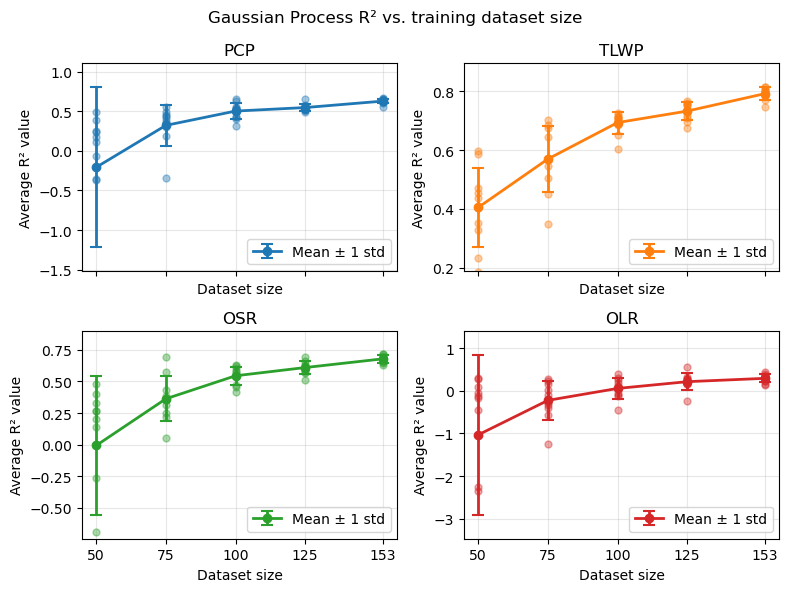

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
axes = axes.flatten()

for ax, var in zip(axes, VAR_NAMES):
    color    = colors.get(var)
    sub_agg  = agg[agg['variable'] == var].sort_values('subset_size')
    sub_seed = seed_means[seed_means['variable'] == var]

    # individual per-seed mean dots
    ax.scatter(sub_seed['subset_size'], sub_seed['seed_mean_r2_phys'],
               color=color, alpha=0.4, s=25, zorder=2)
    # mean ± std line
    ax.errorbar(sub_agg['subset_size'], sub_agg['mean_r2_phys'], yerr=sub_agg['std_r2_phys'],
                color=color, linewidth=2, marker='o', zorder=3,
                capsize=4, capthick=1.5, label='Mean ± 1 std')

    lo = (sub_agg['mean_r2_phys'] - sub_agg['std_r2_phys']).min()
    hi = (sub_agg['mean_r2_phys'] + sub_agg['std_r2_phys']).max()
    pad = (hi - lo) * 0.15
    ax.set_ylim(lo - pad, hi + pad)

    ax.set_title(var) #, fontweight='bold')
    ax.set_ylabel('Average R² value')
    ax.set_xlabel('Dataset size')
    ax.set_xticks(SUBSET_SIZES)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='lower right')

fig.suptitle('Gaussian Process R² vs. training dataset size') # over 10 random seeds\n'
             #'(dots = per-seed means, line = mean ± std across seeds)', fontsize=12)
plt.tight_layout()
plt.show()